In [3]:
#------------------------------
# QUESTION 1: AND Gate Learning
#------------------------------

import numpy as np
import tensorflow as tf
from tensorflow import keras

# 1. Create Dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)

y = np.array([[0],
              [0],
              [0],
              [1]], dtype=np.float32)

# 2. Build Neural Network
model = keras.Sequential([
    keras.layers.Dense(2, activation='relu', input_shape=(2,)),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train Model
history = model.fit(X, y, epochs=500, verbose=0)

# 4. Evaluate Model
loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

# Compare Predictions with Actual Outputs
predictions = model.predict(X)
predictions_binary = (predictions > 0.5).astype(int)

print("\nActual Outputs:")
print(y.flatten())

print("\nPredicted Outputs (probabilities):")
print(predictions.flatten())

print("\nPredicted Outputs (binary):")
print(predictions_binary.flatten())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Actual Outputs:
[0. 0. 0. 1.]

Predicted Outputs (probabilities):
[0.38661665 0.43945482 0.4123183  0.5603064 ]

Predicted Outputs (binary):
[0 0 0 1]


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


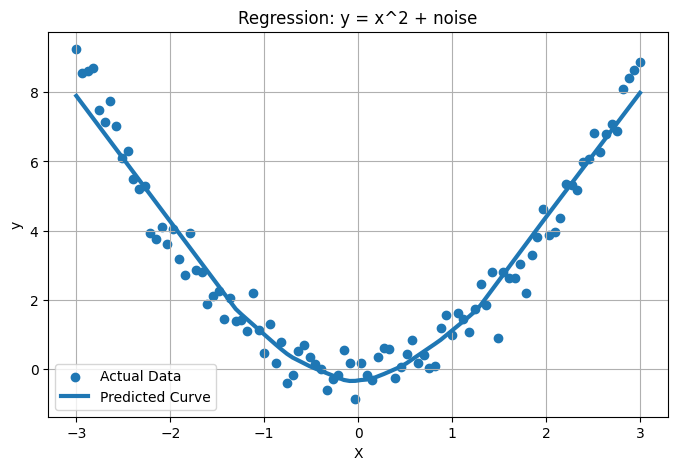

Final Loss (MSE): 0.351444810628891


In [4]:
#--------------------------------------------
# QUESTION 2: Regression y = x^2 + noise
#--------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# 1. Generate Dataset
np.random.seed(42)

# Generate 100 points in [-3, 3]
X = np.linspace(-3, 3, 100).reshape(-1, 1)

# y = x^2 + noise
noise = np.random.normal(0, 0.5, X.shape)
y = X**2 + noise

# 2. Build Neural Network
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(1,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 3. Train Model
history = model.fit(X, y, epochs=300, verbose=0)

# Predict
y_pred = model.predict(X)

# 4. Plot Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(X, y, label='Actual Data')
plt.plot(X, y_pred, label='Predicted Curve', linewidth=3)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression: y = x^2 + noise")
plt.legend()
plt.grid(True)
plt.show()

# Print final loss
print("Final Loss (MSE):", history.history['loss'][-1])



Training XOR model with activation = sigmoid
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Final loss: 0.0010, final accuracy: 1.0000, convergence_epoch: 63
Predicted probs: [8.000e-04 9.988e-01 9.992e-01 1.200e-03]
Predicted binary: [0 1 1 0]

Training XOR model with activation = tanh


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Final loss: 0.0003, final accuracy: 1.0000, convergence_epoch: 16
Predicted probs: [4.000e-04 9.996e-01 9.998e-01 3.000e-04]
Predicted binary: [0 1 1 0]

Training XOR model with activation = relu


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Final loss: 0.0009, final accuracy: 1.0000, convergence_epoch: 3
Predicted probs: [2.800e-03 9.997e-01 9.997e-01 2.000e-04]
Predicted binary: [0 1 1 0]


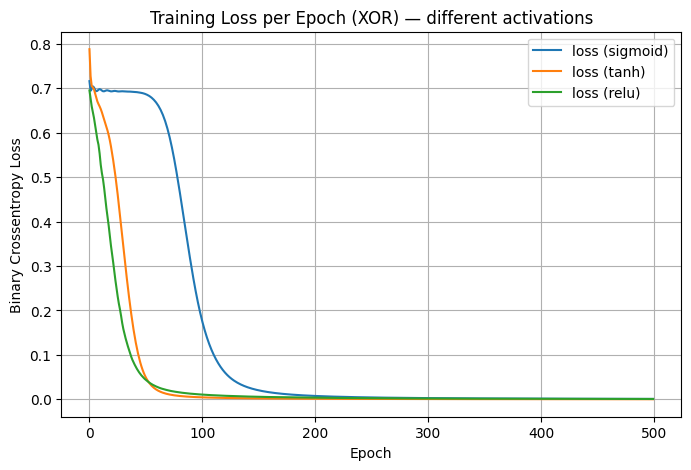

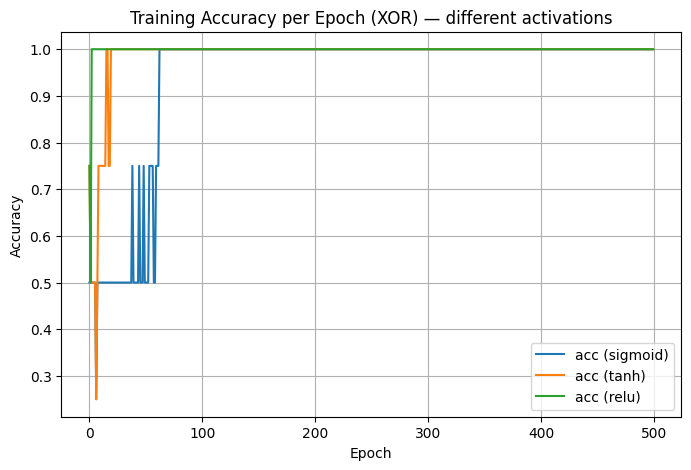



=== Summary Comparison ===

Activation: sigmoid
  Final loss   : 0.0010
  Final acc    : 1.0000
  Converged to perfect accuracy at epoch: 63
  Predictions (prob): [8.000e-04 9.988e-01 9.992e-01 1.200e-03]
  Predictions (bin) : [0 1 1 0]

Activation: tanh
  Final loss   : 0.0003
  Final acc    : 1.0000
  Converged to perfect accuracy at epoch: 16
  Predictions (prob): [4.000e-04 9.996e-01 9.998e-01 3.000e-04]
  Predictions (bin) : [0 1 1 0]

Activation: relu
  Final loss   : 0.0009
  Final acc    : 1.0000
  Converged to perfect accuracy at epoch: 3
  Predictions (prob): [2.800e-03 9.997e-01 9.997e-01 2.000e-04]
  Predictions (bin) : [0 1 1 0]
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 669us/step


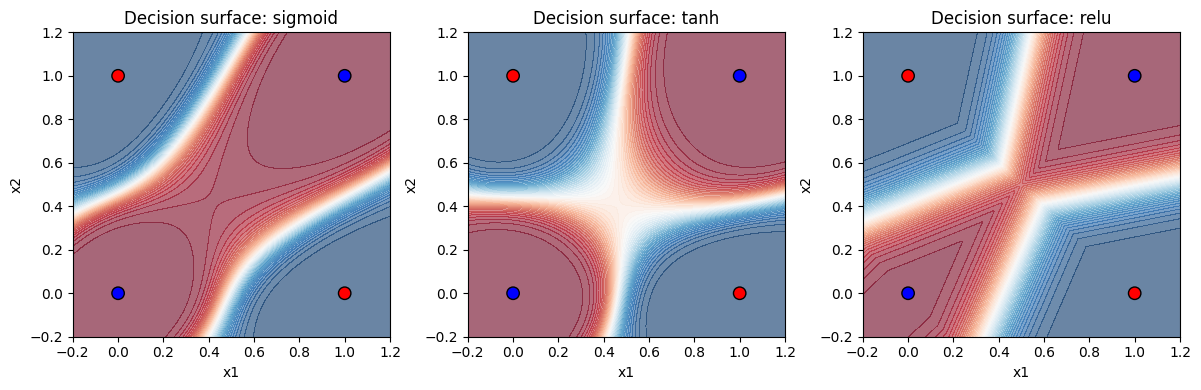



Discussion / Observations:
- XOR is not linearly separable, so a hidden layer is required.
- sigmoid: smooth saturating behaviour. It can learn XOR but may train slower and can suffer from saturation if LR is large.
- tanh: zero-centered activation; often trains better than sigmoid for small nets and can converge faster or stably.
- ReLU: piecewise-linear; often converges faster in deeper networks. For tiny networks it can still work, but if hidden neurons output 0 (dead ReLU) it may stall; using a few hidden units and proper LR usually avoids that.
- Convergence speed (epoch when acc==1.0) is printed above. Compare the 'convergence_epoch' values to see which activation reached perfect accuracy faster.
- Loss curves show training dynamics; accuracy curves show how quickly correct classification is achieved.


In [5]:
# ------------------------------
# QUESTION 3 — XOR with different activations
# ------------------------------
# Colab-ready cell. Paste & run.

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# XOR dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=np.float32)
y = np.array([0,1,1,0], dtype=np.float32)

# helper: build model with given hidden activation
def build_xor_model(hidden_activation, hidden_units=8, lr=0.05):
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(hidden_units, activation=hidden_activation),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Train configs
activations = ['sigmoid', 'tanh', 'relu']
histories = {}
models = {}
results = {}

# We'll train for enough epochs to observe behavior; capture per-epoch metrics
EPOCHS = 500

for act in activations:
    print(f"\nTraining XOR model with activation = {act}")
    m = build_xor_model(act, hidden_units=8, lr=0.05)
    h = m.fit(X, y, epochs=EPOCHS, batch_size=4, verbose=0)
    models[act] = m
    histories[act] = h.history

    # Evaluate on training set (small dataset)
    loss, acc = m.evaluate(X, y, verbose=0)
    preds_prob = m.predict(X).flatten()
    preds_bin = (preds_prob > 0.5).astype(int)

    # Determine convergence speed: first epoch index where accuracy==1.0 (if any)
    acc_history = np.array(h.history['accuracy'])
    conv_epoch = None
    matches = np.where(acc_history >= 0.9999)[0]  # treat >= ~1.0 as converged
    if len(matches) > 0:
        conv_epoch = int(matches[0]) + 1  # +1 for 1-indexed epoch
    results[act] = {
        'loss': float(loss),
        'accuracy': float(acc),
        'predictions_prob': preds_prob,
        'predictions_bin': preds_bin,
        'convergence_epoch': conv_epoch
    }
    print(f"Final loss: {loss:.4f}, final accuracy: {acc:.4f}, convergence_epoch: {conv_epoch}")
    print("Predicted probs:", np.round(preds_prob, 4))
    print("Predicted binary:", preds_bin)

# -------------------------
# Plot loss curves (combined)
# -------------------------
plt.figure(figsize=(8,5))
for act in activations:
    plt.plot(histories[act]['loss'], label=f'loss ({act})')
plt.title('Training Loss per Epoch (XOR) — different activations')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# Plot accuracy curves (combined)
# -------------------------
plt.figure(figsize=(8,5))
for act in activations:
    plt.plot(histories[act]['accuracy'], label=f'acc ({act})')
plt.title('Training Accuracy per Epoch (XOR) — different activations')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# Print a compact comparison table
# -------------------------
print("\n\n=== Summary Comparison ===")
for act in activations:
    r = results[act]
    print(f"\nActivation: {act}")
    print(f"  Final loss   : {r['loss']:.4f}")
    print(f"  Final acc    : {r['accuracy']:.4f}")
    conv = r['convergence_epoch']
    if conv is None:
        print("  Converged to perfect accuracy: NO (within training epochs)")
    else:
        print(f"  Converged to perfect accuracy at epoch: {conv}")
    print(f"  Predictions (prob): {np.round(r['predictions_prob'],4)}")
    print(f"  Predictions (bin) : {r['predictions_bin']}")

# -------------------------
# Decision boundary visualization (optional)
# -------------------------
# Visualize model decision boundary for each activation (grid).
xx, yy = np.meshgrid(np.linspace(-0.2,1.2,200), np.linspace(-0.2,1.2,200))
grid = np.c_[xx.ravel(), yy.ravel()]

plt.figure(figsize=(12,4))
for i, act in enumerate(activations, 1):
    ax = plt.subplot(1,3,i)
    m = models[act]
    probs = m.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=50, cmap='RdBu', alpha=0.6)
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k', s=80)
    ax.set_title(f"Decision surface: {act}")
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.tight_layout()
plt.show()

# -------------------------
# Short discussion printed
# -------------------------
print("\n\nDiscussion / Observations:")
print("- XOR is not linearly separable, so a hidden layer is required.")
print("- sigmoid: smooth saturating behaviour. It can learn XOR but may train slower and can suffer from saturation if LR is large.")
print("- tanh: zero-centered activation; often trains better than sigmoid for small nets and can converge faster or stably.")
print("- ReLU: piecewise-linear; often converges faster in deeper networks. For tiny networks it can still work, but if hidden neurons output 0 (dead ReLU) it may stall; using a few hidden units and proper LR usually avoids that.")
print("- Convergence speed (epoch when acc==1.0) is printed above. Compare the 'convergence_epoch' values to see which activation reached perfect accuracy faster.")
print("- Loss curves show training dynamics; accuracy curves show how quickly correct classification is achieved.")


TensorFlow version: 2.19.0
Target names: ['malignant' 'benign']
Feature shape: (569, 30)

Dataset head:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Class distribution:
1    357
0    212
Name: count, dtype: int64


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5412 - loss: 0.6817 - val_accuracy: 0.8478 - val_loss: 0.4556
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8772 - loss: 0.4367 - val_accuracy: 0.8696 - val_loss: 0.3160
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9306 - loss: 0.2835 - val_accuracy: 0.9130 - val_loss: 0.2438
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9414 - loss: 0.2071 - val_accuracy: 0.9130 - val_loss: 0.2022
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9527 - loss: 0.1559 - val_accuracy: 0.9348 - val_loss: 0.1751
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9480 - loss: 0.1531 - val_accuracy: 0.9565 - val_loss: 0.1524
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9621 - loss: 0.1168 - val_accuracy: 0.9565 - val_loss: 0.1338
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9573 - loss: 0.0972 - val_accuracy: 0.9565 - 

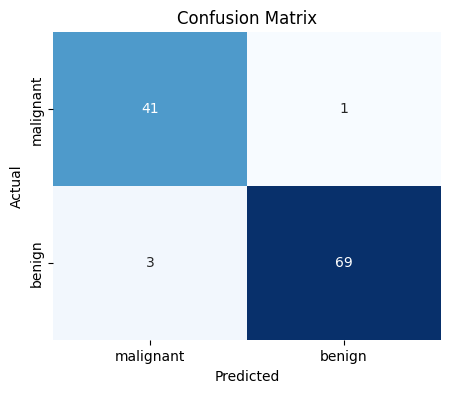

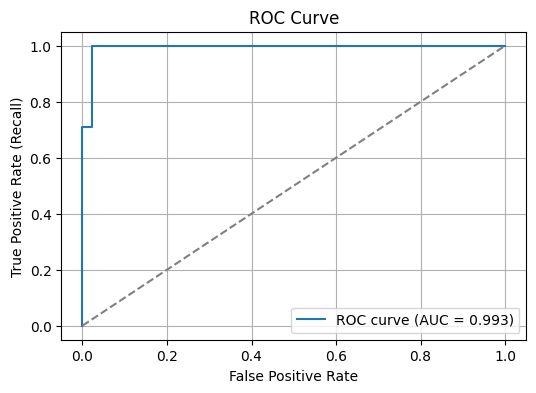

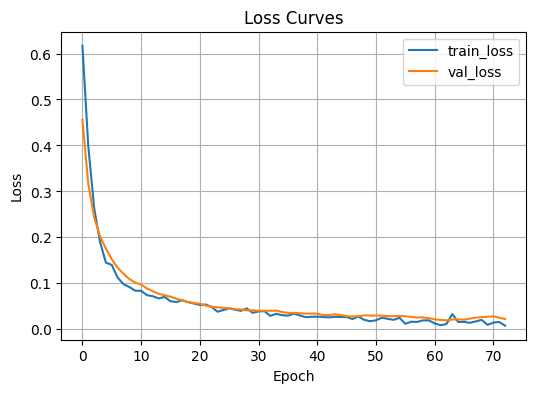

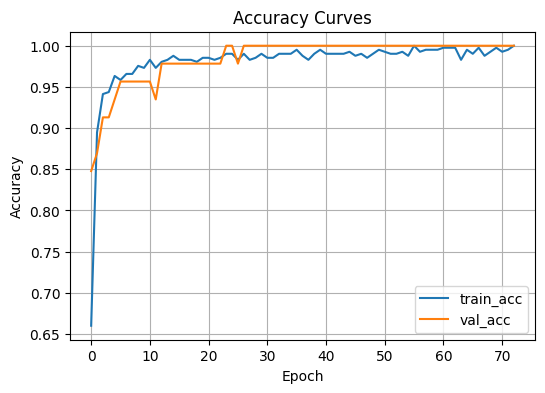


Model and scaler saved as 'breast_cancer_model.h5' and 'scaler_bc.save'.

Tips to improve or productionize:
- Try different architectures (deeper/shallow), tune units and learning rate.
- Use class_weights or oversampling if classes are imbalanced.
- Use cross-validation (StratifiedKFold) for robust estimates.
- Try regularization (L2) and more dropout if overfitting.
- Consider calibrating probabilities (Platt scaling) for better probability estimates.
- For deployment: wrap scaler + model into a single pipeline and serve with Flask/FastAPI or convert to TF Lite/TF Serving.


In [6]:
# ===============================
# QUESTION 4 — Breast Cancer Classification (Colab-ready)
# ===============================
# Paste this cell into Google Colab and run.

# Optional installs (Colab usually has these)
!pip install -q tensorflow scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report
)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

# -----------------------
# 1) Load dataset
# -----------------------
bc = datasets.load_breast_cancer(as_frame=True)
X = bc.data.values       # features
y = bc.target.values     # 0 = malignant? (check target_names), sklearn's target: 0=malignant,1=benign (verify below)
print("Target names:", bc.target_names)
print("Feature shape:", X.shape)

# Quick EDA (optional)
df = bc.frame
print("\nDataset head:")
display(df.head())

print("\nClass distribution:")
print(pd.Series(y).value_counts())

# -----------------------
# 2) Train/test split & scaling
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# -----------------------
# 3) Build the neural network
# -----------------------
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')   # binary output
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model(X_train_s.shape[1])
model.summary()

# -----------------------
# 4) Train with EarlyStopping
# -----------------------
early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=32,
    callbacks=[early],
    verbose=1
)

# -----------------------
# 5) Evaluate on test set
# -----------------------
# Predict probabilities and binary labels
y_prob = model.predict(X_test_s).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nTest accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=bc.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------
# 6) Plot training curves
# -----------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves'); plt.legend(); plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curves'); plt.legend(); plt.grid(True)
plt.show()

# -----------------------
# 7) Save model & scaler (optional)
# -----------------------
model.save('breast_cancer_model.h5')
import joblib
joblib.dump(scaler, 'scaler_bc.save')

print("\nModel and scaler saved as 'breast_cancer_model.h5' and 'scaler_bc.save'.")

# -----------------------
# 8) Tips & improvements (print)
# -----------------------
print("\nTips to improve or productionize:")
print("- Try different architectures (deeper/shallow), tune units and learning rate.")
print("- Use class_weights or oversampling if classes are imbalanced.")
print("- Use cross-validation (StratifiedKFold) for robust estimates.")
print("- Try regularization (L2) and more dropout if overfitting.")
print("- Consider calibrating probabilities (Platt scaling) for better probability estimates.")
print("- For deployment: wrap scaler + model into a single pipeline and serve with Flask/FastAPI or convert to TF Lite/TF Serving.")


Dataset Head:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Class counts:
0    50
1    50
2    50
Name: count, dtype: int64


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2912 - loss: 1.1259 - val_accuracy: 0.0833 - val_loss: 1.0701
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3142 - loss: 0.9422 - val_accuracy: 0.4167 - val_loss: 0.9255
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5885 - loss: 0.7992 - val_accuracy: 0.5833 - val_loss: 0.7956
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7037 - loss: 0.6798 - val_accuracy: 0.6667 - val_loss: 0.6845
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7711 - loss: 0.5825 - val_accuracy: 0.7500 - val_loss: 0.5936
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8127 - loss: 0.5043 - val_accuracy: 0.7500 - val_loss: 0.5192
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9000 - loss: 0.4414 - val_accuracy: 0.7500 - val_loss: 0.4602
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9111 - loss: 0.3915 - val_accuracy: 0.8333 - 

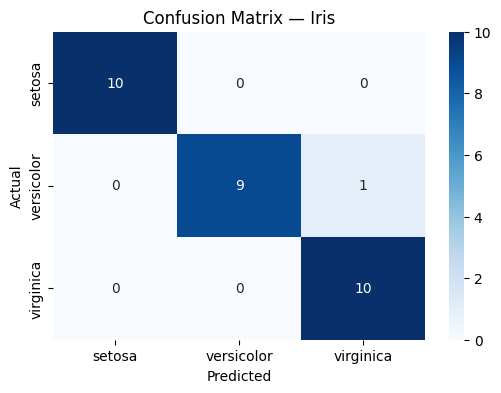

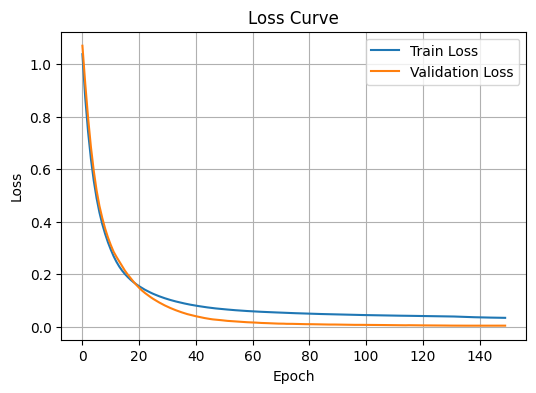

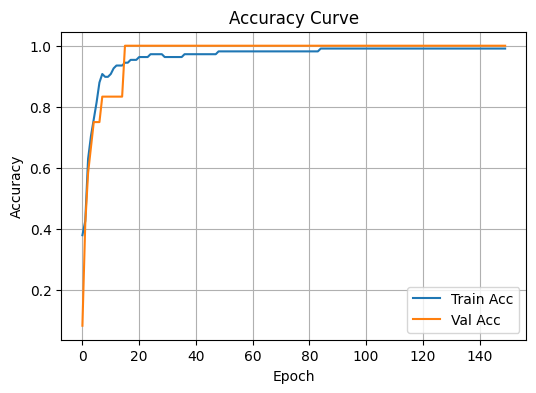


Saved model as iris_model.h5 and scaler as iris_scaler.save


In [7]:
# ===============================================
# QUESTION 5 — Iris Multi-Class Classification
# ===============================================

!pip install -q tensorflow scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

# --------------------
# 1) Load Dataset
# --------------------
iris = datasets.load_iris(as_frame=True)
X = iris.data.values
y = iris.target.values  # labels 0,1,2

df = iris.frame
print("Dataset Head:")
display(df.head())

print("\nClass counts:")
print(pd.Series(y).value_counts())

# --------------------
# 2) Train-test split
# --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Convert y to one-hot for neural net
y_train_cat = keras.utils.to_categorical(y_train, 3)
y_test_cat = keras.utils.to_categorical(y_test, 3)

# --------------------
# 3) Build Neural Network
# --------------------
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')  # 3 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# --------------------
# 4) Train Model
# --------------------
history = model.fit(
    X_train_s, y_train_cat,
    validation_split=0.1,
    epochs=150,
    batch_size=8,
    verbose=1
)

# --------------------
# 5) Evaluate Model
# --------------------
y_prob = model.predict(X_test_s)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Iris")
plt.show()

# --------------------
# 6) Plot Training Curves
# --------------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# --------------------
# 7) Save Model (optional)
# --------------------
model.save("iris_model.h5")
import joblib
joblib.dump(scaler, "iris_scaler.save")

print("\nSaved model as iris_model.h5 and scaler as iris_scaler.save")


Dataset Head:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Feature shape: (20640, 8)
Target shape: (20640,)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.8395 - mae: 0.9718 - mse: 1.8395 - val_loss: 0.4708 - val_mae: 0.4809 - val_mse: 0.4708
Epoch 2/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4126 - mae: 0.4583 - mse: 0.4126 - val_loss: 0.4165 - val_mae: 0.4493 - val_mse: 0.4165
Epoch 3/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3658 - mae: 0.4287 - mse: 0.3658 - val_loss: 0.3963 - val_mae: 0.4374 - val_mse: 0.3963
Epoch 4/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3463 - mae: 0.4156 - mse: 0.3463 - val_loss: 0.3743 - val_mae: 0.4235 - val_mse: 0.3743
Epoch 5/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3299 - mae: 0.4035 - mse: 0.3299 - val_loss: 0.3603 - val_mae: 0.4123 - val_mse: 0.3603
Epoch 6/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3164 - mae: 0.3933 - mse: 0.3164 - val_loss: 0.3500 - val_mae: 0.4032 - val_mse: 0.3500
Epoch 7/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3071 - mae: 0.3856 - mse: 0.307

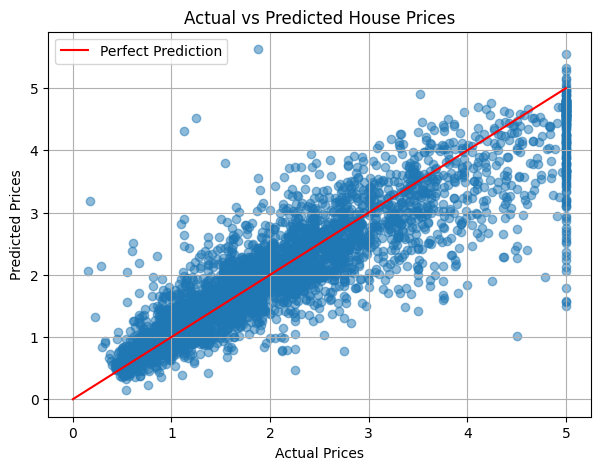

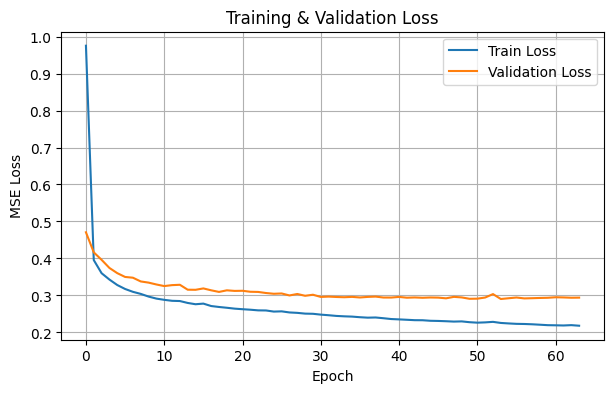


Model saved as california_housing_model.h5
Scaler saved as california_scaler.save


In [8]:
# ========================================
# QUESTION 6 – California Housing Regression
# ========================================

!pip install -q tensorflow scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ------------------------------------
# 1) Load Dataset
# ------------------------------------
data = fetch_california_housing(as_frame=True)
df = data.frame

print("Dataset Head:")
display(df.head())

X = df.drop("MedHouseVal", axis=1).values
y = df["MedHouseVal"].values

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

# ------------------------------------
# 2) Train/Test Split + Scaling
# ------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ------------------------------------
# 3) Build Neural Network
# ------------------------------------
model = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)   # regression → no activation
])

model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])
model.summary()

# ------------------------------------
# 4) Train Model
# ------------------------------------
early = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=64,
    callbacks=[early],
    verbose=1
)

# ------------------------------------
# 5) Evaluation
# ------------------------------------
y_pred = model.predict(X_test_s).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nREGRESSION METRICS:")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# ------------------------------------
# 6) Plot Predictions vs Actual
# ------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0,5], [0,5], color='red', label="Perfect Prediction")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------
# 7) Training Curves
# ------------------------------------
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------
# 8) Save Model
# ------------------------------------
model.save("california_housing_model.h5")
import joblib
joblib.dump(scaler, "california_scaler.save")

print("\nModel saved as california_housing_model.h5")
print("Scaler saved as california_scaler.save")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: (60000, 784)
Test samples: (10000, 784)
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8720 - loss: 0.4330 - val_accuracy: 0.9702 - val_loss: 0.0982
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9700 - loss: 0.0977 - val_accuracy: 0.9750 - val_loss: 0.0852
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9826 - loss: 0.0569 - val_accuracy: 0.9762 - val_loss: 0.0788
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9885 - loss: 0.0361 - val_accuracy: 0.9738 - val_loss: 0.0884
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9921 - loss: 0.0252 - val_accuracy: 0.9778 - val_loss: 0.0766
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9931 - loss: 0.0222 - val_accuracy: 0.9765 - val_loss: 0.0978
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9947 - loss: 0.0177 - val_accuracy: 0.9742 - val_loss: 0.0997
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9948 - loss: 0.0159 - val_accuracy: 0.9770 - v

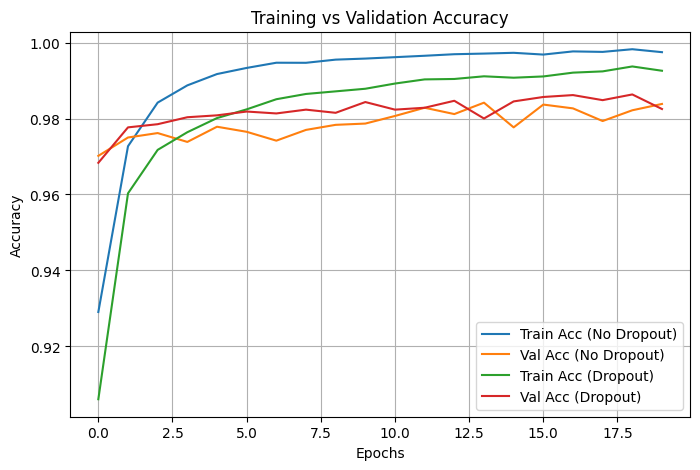

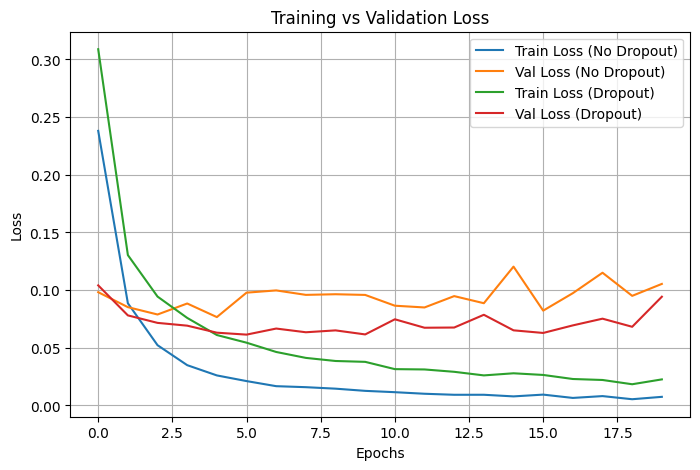


Model saved as mnist_dropout_model.h5


In [9]:
# =========================================
# QUESTION 7 — MNIST with Dropout Regularization
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ------------------------------------
# 1) Load MNIST Dataset
# ------------------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Flatten images (28x28 → 784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training samples:", x_train.shape)
print("Test samples:", x_test.shape)

# ------------------------------------
# 2) Build Model WITHOUT Dropout
# ------------------------------------
model_no_dropout = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_no_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------
# 3) Train Model WITHOUT Dropout
# ------------------------------------
history_no = model_no_dropout.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

# ------------------------------------
# 4) Build Model WITH Dropout
# ------------------------------------
model_dropout = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------
# 5) Train Model WITH Dropout
# ------------------------------------
history_drop = model_dropout.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

# ------------------------------------
# 6) Evaluate Both Models
# ------------------------------------
print("\n--- MODEL WITHOUT DROPOUT ---")
loss_no, acc_no = model_no_dropout.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc_no:.4f} | Test Loss: {loss_no:.4f}")

print("\n--- MODEL WITH DROPOUT ---")
loss_drop, acc_drop = model_dropout.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {acc_drop:.4f} | Test Loss: {loss_drop:.4f}")

# ------------------------------------
# 7) Plot Accuracy Comparison
# ------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_no.history['accuracy'], label="Train Acc (No Dropout)")
plt.plot(history_no.history['val_accuracy'], label="Val Acc (No Dropout)")
plt.plot(history_drop.history['accuracy'], label="Train Acc (Dropout)")
plt.plot(history_drop.history['val_accuracy'], label="Val Acc (Dropout)")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# ------------------------------------
# 8) Plot Loss Comparison
# ------------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_no.history['loss'], label="Train Loss (No Dropout)")
plt.plot(history_no.history['val_loss'], label="Val Loss (No Dropout)")
plt.plot(history_drop.history['loss'], label="Train Loss (Dropout)")
plt.plot(history_drop.history['val_loss'], label="Val Loss (Dropout)")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ------------------------------------
# 9) Save Best Model
# ------------------------------------
model_dropout.save("mnist_dropout_model.h5")
print("\nModel saved as mnist_dropout_model.h5")
